### Пример простого автоэнкодера

Реализуем относительно простой автоэнкодер в виде многосвязной НС для представления изображений цифр из БД MNIST. На этом примере можно наглядно увидеть результат использования сложной нелинейной модели.

In [1]:
import numpy as np
import torch
print('PyTorch version: {}'.format(torch.__version__))
import matplotlib.pyplot as plt
from torch import nn
from torch.nn import functional as F
import torchvision
import torchvision.transforms.v2 as tfs_v2
import torch.utils.data as data
import torch.optim as optim
import torch.nn as nn
from tqdm import tqdm

PyTorch version: 2.2.2+cpu


In [19]:
# Опишем архитектуру автоэнкодера для изображений из набора данных MNIST:
class AutoEncoderMNIST(nn.Module):
    def __init__(self, input_dim, output_dim, hidden_dim):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 128),
            # Используем нелинейность ELU, которая позволяет избежать проблемы затухающего градиента и обеспечивает более быструю сходимость по сравнению с ReLU:
            # inplace=True означает, что операция будет выполняться на месте, то есть без выделения дополнительной памяти для хранения результата, что может улучшить производительность и снизить использование памяти:
            nn.ELU(inplace=True),
            nn.Linear(128, 64),
            nn.ELU(inplace=True),
            nn.Linear(64, self.hidden_dim)
        )
 
        self.decoder = nn.Sequential(
            nn.Linear(self.hidden_dim, 64),
            nn.ELU(inplace=True),
            nn.Linear(64, 128),
            nn.ELU(inplace=True),
            nn.Linear(128, output_dim),
            nn.Sigmoid()
        )
 
    def forward(self, x):
        h = self.encoder(x)
        x = self.decoder(h)
 
        return x, h

Здесь класс nn.ELU описывает функцию активации ELU(x) вида:

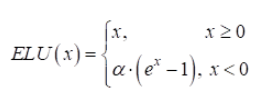

In [20]:
# После этого создадим модель и сформируем обучающую выборку:
model_ae = AutoEncoderMNIST(28 * 28, 28 * 28, 28)
# Для загрузки изображений из набора данных MNIST и их преобразования в формат, подходящий для обучения автоэнкодера, используем следующие трансформации:
# tfs_v2 - это модуль трансформаций из библиотеки torchvision, который предоставляет различные функции для обработки изображений, такие как изменение размера, нормализация, аугментация и т.д. В данном случае мы используем следующие трансформации:
# ToImage() - преобразует входные данные в формат изображения, который может быть обработан нейронной сетью.
# ToDtype(dtype=torch.float32, scale=True) - преобразует данные в тип данных float32 и масштабирует их значения в диапазон от 0 до 1, что является стандартной практикой при работе с изображениями в нейронных сетях.
# Lambda(lambda _img: _img.ravel()) - применяет функцию, которая преобразует изображение в одномерный массив (вектор), что необходимо для подачи данных в полносвязные слои автоэнкодера.
transforms_ae = tfs_v2.Compose(
    [tfs_v2.ToImage(),
    tfs_v2.ToDtype(dtype=torch.float32, scale=True),
    tfs_v2.Lambda(lambda _img: _img.ravel())]
       )
 
d_train = torchvision.datasets.MNIST(r'C:\datasets\mnist', download=True, train=True, transform=transforms_ae)
train_data = data.DataLoader(d_train, batch_size=32, shuffle=True)

In [21]:
# Зададим оптимизатор, функцию потерь, в виде средней квадратической ошибки, пять эпох обучения, и переведем модель в режим обучения:
optimizer = optim.Adam(params=model_ae.parameters(), lr=0.001)
loss_func = nn.MSELoss()
 
epochs = 5
model_ae.train()

AutoEncoderMNIST(
  (encoder): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ELU(alpha=1.0, inplace=True)
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ELU(alpha=1.0, inplace=True)
    (4): Linear(in_features=64, out_features=28, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=28, out_features=64, bias=True)
    (1): ELU(alpha=1.0, inplace=True)
    (2): Linear(in_features=64, out_features=128, bias=True)
    (3): ELU(alpha=1.0, inplace=True)
    (4): Linear(in_features=128, out_features=784, bias=True)
    (5): Sigmoid()
  )
)

In [22]:
# Запишем главный цикл обучения знакомым нам образом:
for _e in range(epochs):
    loss_mean = 0
    lm_count = 0
 
    train_tqdm = tqdm(train_data, leave=True)
    for x_train, y_train in train_tqdm:
        predict, _ = model_ae(x_train)
        loss = loss_func(predict, x_train)
 
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
 
        lm_count += 1
        loss_mean = 1/lm_count * loss.item() + (1 - 1/lm_count) * loss_mean
        train_tqdm.set_description(f"Epoch [{_e+1}/{epochs}], loss_mean={loss_mean:.3f}")

Epoch [5/5], loss_mean=0.011: 100%|██████████| 1875/1875 [00:15<00:00, 119.35it/s]


In [23]:
# Сохраним обученную модель:
st = model_ae.state_dict()
torch.save(st, 'model_autoencoder.tar')

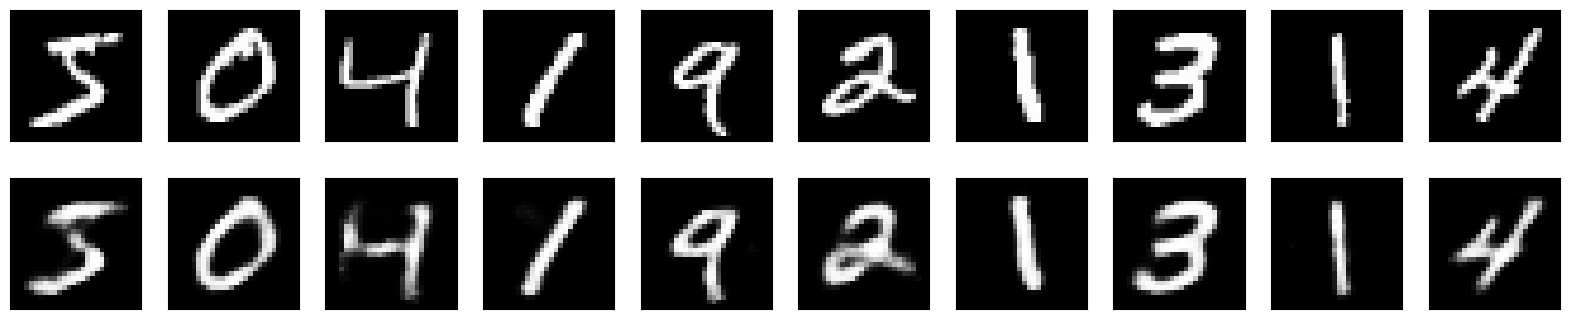

In [24]:
# отобразим первые 10 изображений с результатом их декодирования обученным автоэнкодером
n = 10
model_ae.eval()
 
plt.figure(figsize=(2*n, 2*2))
for i in range(n):
    # img - это входное изображение, а predict - это результат его декодирования автоэнкодером. 
    # Мы используем функцию unsqueeze(0), чтобы добавить дополнительное измерение к изображению, так как модель ожидает вход в виде батча (даже если он состоит из одного изображения). 
    # Затем мы удаляем это дополнительное измерение с помощью функции squeeze(0) и изменяем форму результата на 28x28 для отображения.
    img, _ = d_train[i]
    predict, _ = model_ae(img.unsqueeze(0))
 
    predict = predict.squeeze(0).view(28, 28)
    img = img.view(28, 28)
 
    dec_img = predict.detach().numpy()
    img = img.detach().numpy()
 
    ax = plt.subplot(2, n, i+1)
    plt.imshow(img, cmap='gray')
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
 
    ax2 = plt.subplot(2, n, i+n+1)
    plt.imshow(dec_img, cmap='gray')
    ax2.get_xaxis().set_visible(False)
    ax2.get_yaxis().set_visible(False)
 
plt.show()


Для объяснения возможности сжатия входного сигнала до вектора размера 28 можно представить его как точку в 784-мерном пространстве. Большинство точек этого пространства будут соответствовать шумовым, непонятным изображениям и только малая их часть соответствует цифрам. Кодер в процессе обучения пытается «уловить» область определения этих цифр в многомерном пространстве и представить их в 28-мерном пространстве вектора скрытого состояния

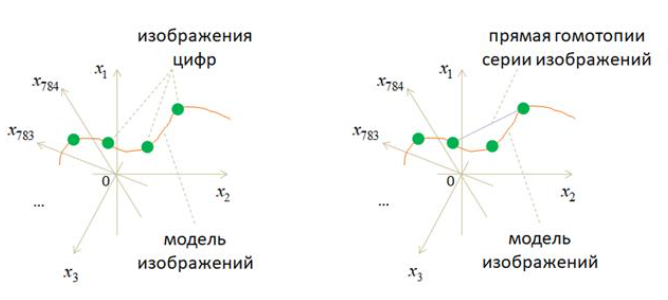



Теперь рассмотрим область, которую формирует кодер при преобразовании таких изображений.

In [25]:
# Для этого переведем модель в режим эксплуатации и сформируем набор из всех тестовых данных для последующего отображения результатов декодирования:
d_test = torchvision.datasets.MNIST(r'C:\datasets\mnist', download=True, train=False, transform=transforms_ae)
x_data = transforms_ae(d_test.data).view(len(d_test), -1)

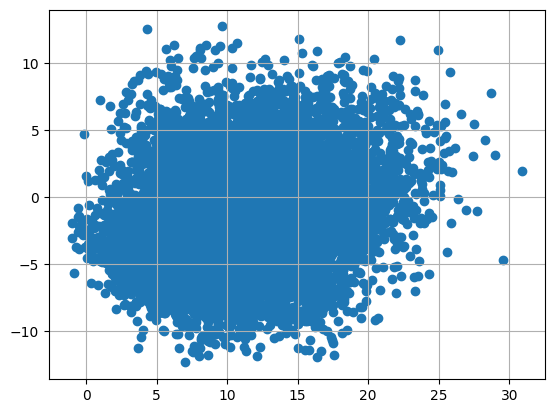

In [26]:
# А, затем, пропустим их только через кодер и отобразим в двумерном пространстве полученные значения векторов скрытого состояния:
h = model_ae.encoder(x_data)
h = h.detach().numpy()
 
plt.scatter(h[:, 0], h[:, 1])
plt.grid()
plt.show()

Это характерная картина формирования модельной области отображения входного сигнала в пространство скрытого состояния. Из этого следует если мы будем брать точки в пределах сформированной области, то, скорее всего, на выходе декодера будут получаться осмысленные изображения цифр. Если же брать точку за пределами этой области, то очень вероятно получим какое-то неопределенное изображение. Например, для точки с координатами h = [-15, 10]

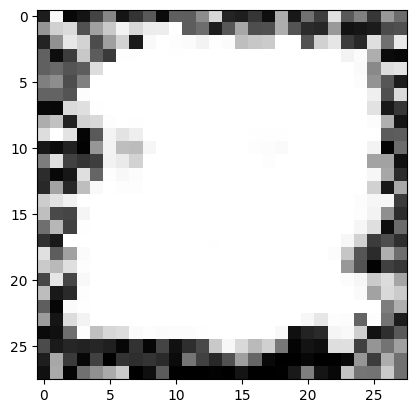

In [28]:
h = torch.zeros(28, dtype=torch.float32)
h[0] = -15
h[1] = 10

predict = model_ae.decoder(h.unsqueeze(0))
predict = predict.detach().squeeze(0).view(28, 28)
dec_img = predict.numpy()
plt.imshow(dec_img, cmap='gray')
plt.show()

Напоминает смесь каких-то цифр и выглядит не очень. Из-за этого автоэнкодеры в чистом виде не практичны для генерации произвольных изображений. То есть, мы не можем брать произвольные точки в области скрытого состояния, чтобы гарантированно получать осмысленные изображения. Чтобы решить эту проблему пространство состояний скрытого вектора должно быть компактным и представлять единую цельную область без существенных разделений. Именно эту цель преследуют вариационные автоэнкодеры.

# Реализация вариационного автоэнкодера

In [2]:
class VAutoEncoderMNIST(nn.Module):
    def __init__(self, input_dim, output_dim, hidden_dim):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ELU(inplace=True),
            nn.BatchNorm1d(128),
            nn.Linear(128, 64),
            nn.ELU(inplace=True),
            nn.BatchNorm1d(64)
        )
 
        self.h_mean = nn.Linear(64, self.hidden_dim)
        self.h_log_var = nn.Linear(64, self.hidden_dim)
 
        self.decoder = nn.Sequential(
            nn.Linear(self.hidden_dim, 64),
            nn.ELU(inplace=True),
            nn.BatchNorm1d(64),
            nn.Linear(64, 128),
            nn.ELU(inplace=True),
            nn.BatchNorm1d(128),
            nn.Linear(128, output_dim),
            nn.Sigmoid()
        )
 
    def forward(self, x):
        enc = self.encoder(x)
 
        h_mean = self.h_mean(enc)
        h_log_var = self.h_log_var(enc)
 
        noise = torch.normal(mean=torch.zeros_like(h_mean), std=torch.ones_like(h_log_var))
        h = noise * torch.exp(h_log_var / 2) + h_mean
        x = self.decoder(h)
 
        return x, h, h_mean, h_log_var

Здесь появились отдельные полносвязные слои для формирования среднего значения (h_mean) и логарифма дисперсии разброса (h_log_var) для векторов скрытого состояния. А в методе forward реализована логика обработки входного тензора x и формирования выходного с дополнительным сохранением векторов скрытого состояния, их средних значений и логарифмов дисперсий. Обратите внимание, что мы работаем с логарифмом дисперсии, а не самой дисперсией. Это связано с удобством дальнейших вычислений. Поэтому в строчке:

h = noise * torch.exp(h_log_var / 2) + h_mean - экспонента от h_log_var / 2 соответствует СКО: 

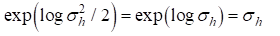

В результате модель работает согласно следующему рисунку:

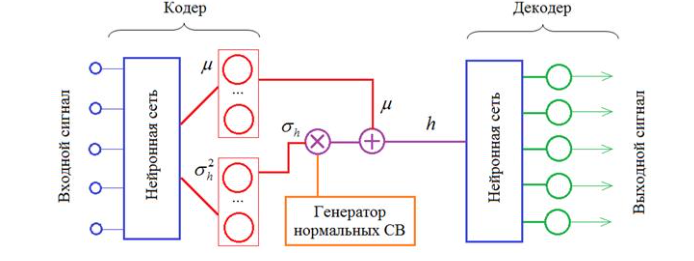

Далее нам нужно сформировать функцию потерь для обучения этой модели. 

In [3]:
class VAELoss(nn.Module):
    def forward(self, x, y, h_mean, h_log_var):
        img_loss = torch.sum(torch.square(x - y), dim=-1)
        kl_loss = -0.5 * torch.sum(1 + h_log_var - torch.square(h_mean) - torch.exp(h_log_var), dim=-1)
        return torch.mean(img_loss + kl_loss)

Мы здесь объединяем ошибку квадрата рассогласования между входным и выходным изображениями, а также дивергенцию Кульбака-Лейблера. В методе forward параметры:

* x – тензор входных данных;
* y – тензор выходных данных;
* h_mean – мини-батч средних значений;
* h_log_var - мини-батч логарифмов дисперсий.

In [29]:
model_vae = VAutoEncoderMNIST(784, 784, 2)
transforms = tfs_v2.Compose([tfs_v2.ToImage(), tfs_v2.ToDtype(dtype=torch.float32, scale=True),
                             tfs_v2.Lambda(lambda _img: _img.ravel())])
 
d_train = torchvision.datasets.MNIST(r'C:\datasets\mnist', download=True, train=True, transform=transforms)
train_data = data.DataLoader(d_train, batch_size=100, shuffle=True)
 
optimizer = optim.Adam(params=model_vae.parameters(), lr=0.001)
loss_func = VAELoss()
 
epochs = 5
model_vae.train()
 
for _e in range(epochs):
    loss_mean = 0
    lm_count = 0
 
    train_tqdm = tqdm(train_data, leave=True)
    for x_train, y_train in train_tqdm:
        predict, _, h_mean, h_log_var = model_vae(x_train)
        loss = loss_func(predict, x_train, h_mean, h_log_var)
 
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
 
        lm_count += 1
        loss_mean = 1/lm_count * loss.item() + (1 - 1/lm_count) * loss_mean
        train_tqdm.set_description(f"Epoch [{_e+1}/{epochs}], loss_mean={loss_mean:.3f}")
 
st = model_vae.state_dict()
torch.save(st, 'model_vae_3.tar')

Epoch [5/5], loss_mean=40.295: 100%|██████████| 600/600 [00:10<00:00, 56.10it/s]


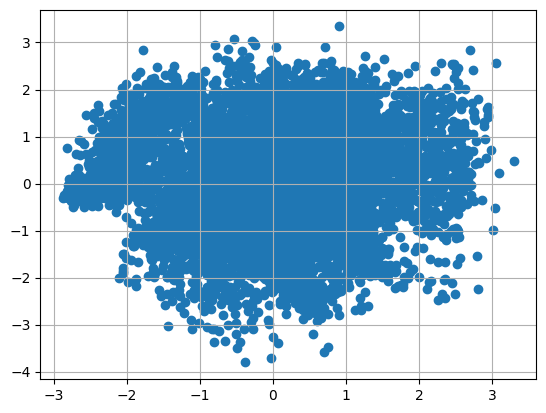

In [30]:
model_vae.eval()
 
d_test = torchvision.datasets.MNIST(r'C:\datasets\mnist', download=True, train=False, transform=transforms)
x_data = transforms(d_test.data).view(len(d_test), -1)
 
_, h, _, _ = model_vae(x_data)
h = h.detach().numpy()

# Отобразим в двумерном пространстве полученные значения векторов скрытого состояния: 
plt.scatter(h[:, 0], h[:, 1])
plt.grid()
plt.show()

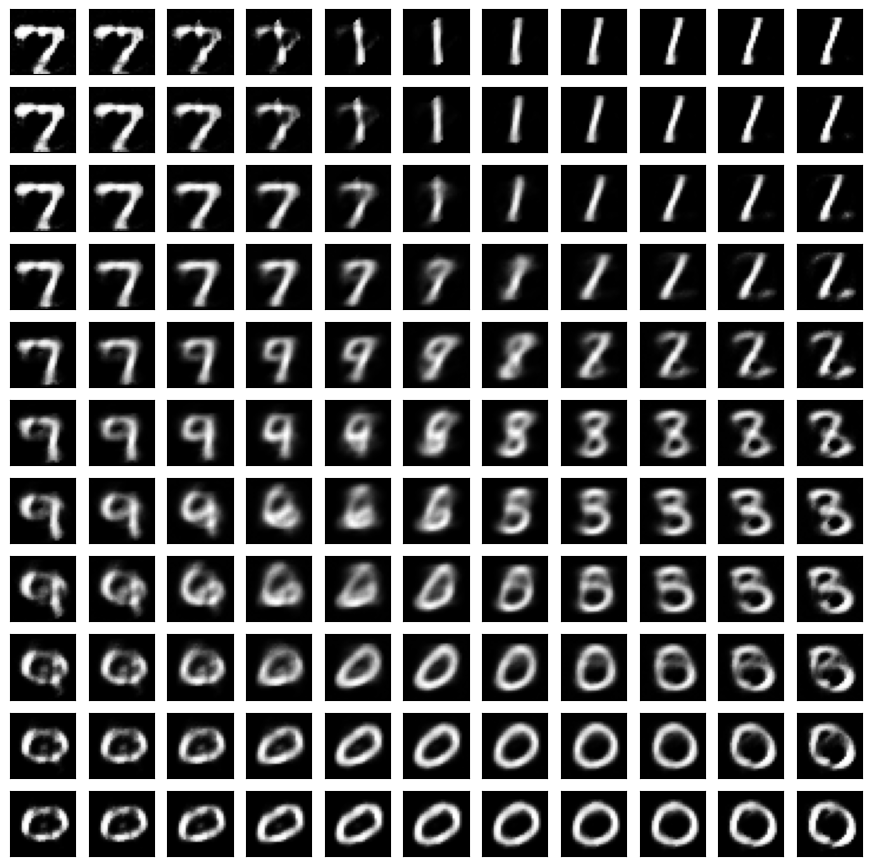

In [31]:
# Сгенерируем изображения, декодируя вектор скрытого состояния, координаты которого изменяются от -3 до 3:
n = 5
total = 2*n+1
 
plt.figure(figsize=(total, total))
 
num = 1
for i in range(-n, n+1):
    for j in range(-n, n+1):
        ax = plt.subplot(total, total, num)
        num += 1
        h = torch.tensor([3*i/n, 3*j/n], dtype=torch.float32)
        predict = model_vae.decoder(h.unsqueeze(0))
        predict = predict.detach().squeeze(0).view(28, 28)
        dec_img = predict.numpy()
 
        plt.imshow(dec_img, cmap='gray')
        ax.get_xaxis().set_visible(False)
        ax.get_yaxis().set_visible(False)
 
plt.show()

В верхнем правом углу образы получились не очень понятные. Это вполне возможно, так как в точке (3; 3) имеем самый край области и там могут быть неопределенные изображения. 

Также видим, что некоторые цифры отсутствуют, а некоторые изображения представляют собой переход из одной цифры в другую. Это вполне естественный результат, так как были выбраны лишь некоторые из точек пространства, которые расположены в областях строго определенных цифр. 

При этом сами цифры группируются в пространстве векторов скрытого состояния.

 Чтобы знать, какая область отвечает за генерацию изображения той или иной цифры, достаточно вычислить ее среднее значение и дисперсию с помощью модели кодера:

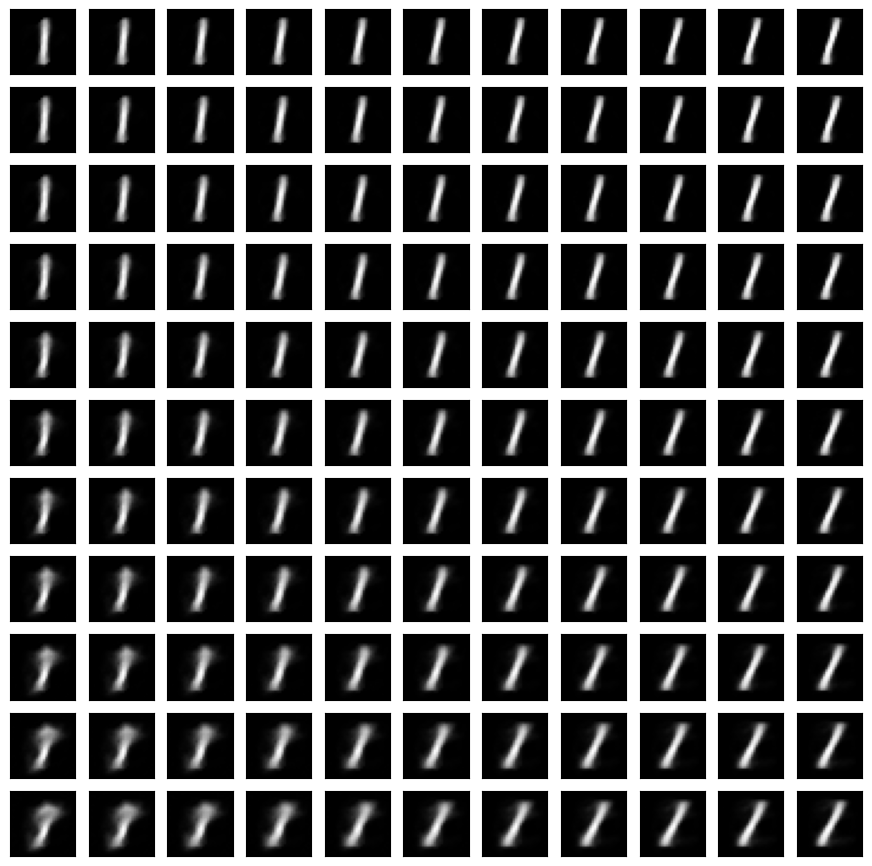

In [32]:
# Теперь, сгенерируем изображения, декодируя вектор скрытого состояния, координаты которого изменяются от -3 до 3, 
# но при этом центрированного относительно среднего значения векторов скрытого состояния для всех изображений класса 1:
x_data = d_train.data[d_train.targets == 1]
batch_size = x_data.size(0)
x_data = transforms(x_data).view(batch_size, -1)
enc = model_vae.encoder(x_data)
h_mean, h_log_var = model_vae.h_mean(enc), model_vae.h_log_var(enc)
 
h_mean = torch.mean(h_mean, dim=0)
h_std = torch.mean(torch.exp(h_log_var / 2), dim=0)
 
n = 5
total = 2*n+1
 
plt.figure(figsize=(total, total))
 
num = 1
for i in range(-n, n+1):
    for j in range(-n, n+1):
        ax = plt.subplot(total, total, num)
        num += 1
        h = torch.tensor([3 * h_std[0] * i/n + h_mean[0], 3 * h_std[1] * j/n + h_mean[1]], dtype=torch.float32)
        predict = model_vae.decoder(h.unsqueeze(0))
        predict = predict.detach().squeeze(0).view(28, 28)
        dec_img = predict.numpy()
 
        plt.imshow(dec_img, cmap='gray')
        ax.get_xaxis().set_visible(False)
        ax.get_yaxis().set_visible(False)
 
plt.show()

# GAN на PyTorch

Схема генеративно-состязательной сети:

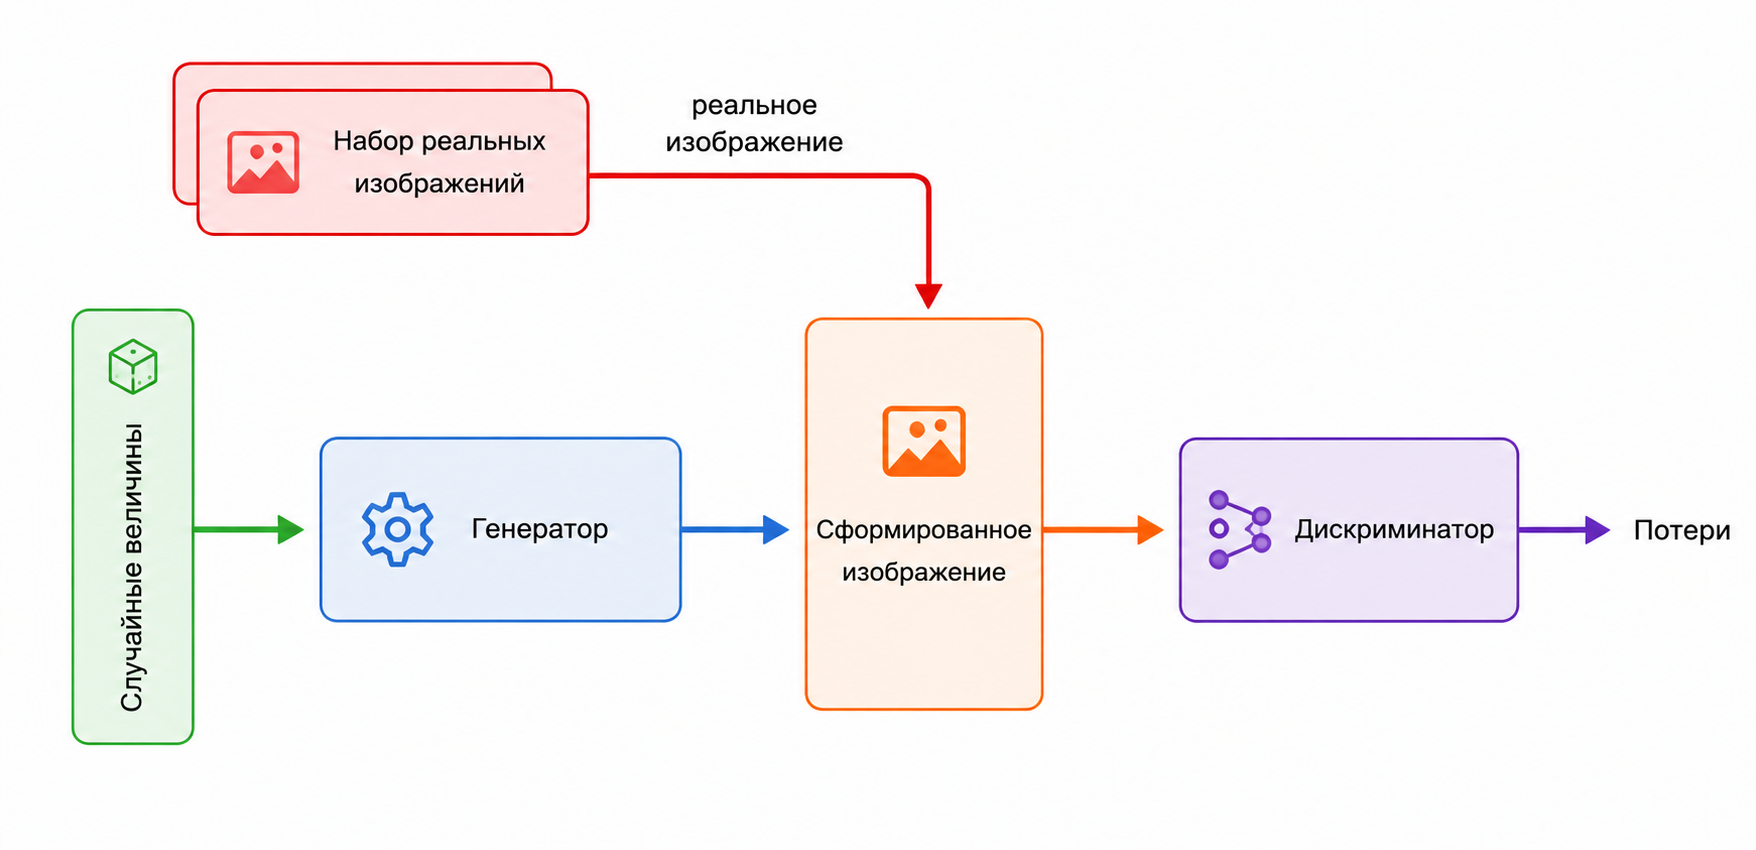

Чтобы генератор лучше формировал изображения, их следует взять однотипными, например, все пятерки. Для этого создадим класс Dataset, возвращающий изображения пятерок из БД MNIST:

In [47]:
class DigitDataset(data.Dataset):
    def __init__(self, path, train=True, target=5, transform=None):
        _dataset = torchvision.datasets.MNIST(path, download=True, train=train)
        self.dataset = _dataset.data[_dataset.targets == target]  # (N, 28, 28), uint8
        self.length = self.dataset.size(0)
        self.target = torch.tensor([target], dtype=torch.float32)
        self.transform = transform  # сохраняем, не применяем сразу

    def __getitem__(self, item):
        img = self.dataset[item]  # (28, 28), uint8
        if self.transform:
            img = self.transform(img)  # → (1, 28, 28), float32
        return img, self.target

    def __len__(self):
        return self.length

In [48]:
transforms = tfs_v2.Compose([tfs_v2.ToImage(), tfs_v2.ToDtype(dtype=torch.float32, scale=True)])
d_train = DigitDataset(r'C:\datasets\mnist', train=True, transform=transforms)
train_data = data.DataLoader(d_train, batch_size=batch_size, shuffle=True, drop_last=True)

In [ ]:
# Модель генератора будет состоять из полносвязного слоя, который преобразует входной вектор размерности 2 в вектор размерности 512*7*7
#  на входе генератор будет ожидать двумерный вектор из независимых нормальных СВ, размерностью hidden_dim: h = [h1, h2]^T
model_gen = nn.Sequential(
    nn.Linear(2, 512*7*7, bias=False),
    nn.ELU(inplace=True),
    nn.BatchNorm1d(512*7*7),
    nn.Unflatten(1, (512, 7, 7)),
    nn.Conv2d(512, 256, 5, 1, padding='same', bias=False),
    nn.ELU(inplace=True),
    nn.BatchNorm2d(256),
    nn.Conv2d(256, 128, 5, 1, padding='same', bias=False),
    nn.ELU(inplace=True),
    nn.BatchNorm2d(128),
    nn.ConvTranspose2d(128, 64, 4, 2, padding=1, bias=False),
    nn.ELU(inplace=True),
    nn.BatchNorm2d(64),
    nn.ConvTranspose2d(64, 32, 4, 2, padding=1, bias=False),
    nn.ELU(inplace=True),
    nn.BatchNorm2d(32),
    nn.Conv2d(32, 1, 1, 1),
    nn.Sigmoid()
)

In [ ]:
# Модель дискриминатора будет состоять из двух сверточных слоев, которые будут извлекать признаки из входного изображения, и полносвязного слоя, который будет выдавать вероятность того, что изображение является реальным:
# На вход дискриминатора будут подаваться изображения размером 28х28 пикселей, а на выходе формироваться одно числовое значение, которое можно воспринимать, как уверенность дискриминатора в натуральности поданного изображения.
model_dis = nn.Sequential(
    nn.Conv2d(1, 64, 5, 2, padding=2, bias=False),
    nn.ELU(inplace=True),
    nn.BatchNorm2d(64),
    nn.Conv2d(64, 128, 5, 2, padding=2, bias=False),
    nn.ELU(inplace=True),
    nn.BatchNorm2d(128),
    nn.Flatten(),
    nn.Linear(128*7*7, 1),
)

In [37]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
 
model_gen.to(device)
model_dis.to(device)

cpu


Sequential(
  (0): Conv2d(1, 64, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2), bias=False)
  (1): ELU(alpha=1.0, inplace=True)
  (2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (3): Conv2d(64, 128, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2), bias=False)
  (4): ELU(alpha=1.0, inplace=True)
  (5): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (6): Flatten(start_dim=1, end_dim=-1)
  (7): Linear(in_features=6272, out_features=1, bias=True)
)

In [38]:
epochs = 20
hidden_dim = 2
batch_size = 16

In [40]:
# Для обучения GAN нам понадобятся два оптимизатора, по одному для каждой модели. Мы будем использовать оптимизатор Adam, который является популярным выбором для обучения нейронных сетей, включая GAN.
optimizer_gen = optim.Adam(params=model_gen.parameters(), lr=0.001)
optimizer_dis = optim.Adam(params=model_dis.parameters(), lr=0.001)

In [39]:
loss_func = nn.BCEWithLogitsLoss()

In [ ]:
# Для обучения GAN нам также понадобятся целевые метки для реальных и сгенерированных изображений. Обычно, для реальных изображений используется метка 1, а для сгенерированных - метка 0. 
# Мы создадим два тензора, targets_0 и targets_1, которые будут содержать эти метки для всего батча:
targets_0 = torch.zeros(batch_size, 1).to(device)
targets_1 = torch.ones(batch_size, 1).to(device)

In [ ]:
# а также списки для хранения истории изменения функций потерь для генератора и дискриминатора
loss_gen_lst = []
loss_dis_lst = []

In [43]:
model_gen.train()
model_dis.train()

Sequential(
  (0): Conv2d(1, 64, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2), bias=False)
  (1): ELU(alpha=1.0, inplace=True)
  (2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (3): Conv2d(64, 128, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2), bias=False)
  (4): ELU(alpha=1.0, inplace=True)
  (5): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (6): Flatten(start_dim=1, end_dim=-1)
  (7): Linear(in_features=6272, out_features=1, bias=True)
)

In [49]:
for _e in range(epochs):
    loss_mean_gen = 0
    loss_mean_dis = 0
    lm_count = 0
 
    train_tqdm = tqdm(train_data, leave=True)
    for x_train, y_train in train_tqdm:
        x_train = x_train.to(device)
 
        h = torch.normal(mean=torch.zeros((batch_size, hidden_dim)), std=torch.ones((batch_size, hidden_dim)))
        h = h.to(device)
 
        img_gen = model_gen(h)
        fake_out = model_dis(img_gen)
 
        loss_gen = loss_func(fake_out, targets_1)
 
        optimizer_gen.zero_grad()
        loss_gen.backward()
        optimizer_gen.step()
 
        # discriminator learning
        img_gen = model_gen(h)
        fake_out = model_dis(img_gen)
        real_out = model_dis(x_train)
 
        outputs = torch.cat([real_out, fake_out], dim=0).to(device)
        targets = torch.cat([targets_1, targets_0], dim=0).to(device)
 
        loss_dis = loss_func(outputs, targets)
 
        optimizer_dis.zero_grad()
        loss_dis.backward()
        optimizer_dis.step()
 
        lm_count += 1
        loss_mean_gen = 1/lm_count * loss_gen.item() + (1 - 1/lm_count) * loss_mean_gen
        loss_mean_dis = 1/lm_count * loss_dis.item() + (1 - 1/lm_count) * loss_mean_dis
 
        train_tqdm.set_description(f"Epoch [{_e+1}/{epochs}], loss_mean_gen={loss_mean_gen:.3f}, loss_mean_dis={loss_mean_dis:.3f}")
 
    loss_gen_lst.append(loss_mean_gen)
    loss_dis_lst.append(loss_mean_dis)

Epoch [1/20], loss_mean_gen=7.013, loss_mean_dis=0.084: 100%|██████████| 338/338 [00:39<00:00,  8.63it/s]
Epoch [2/20], loss_mean_gen=8.223, loss_mean_dis=0.178: 100%|██████████| 338/338 [00:39<00:00,  8.49it/s]
Epoch [3/20], loss_mean_gen=7.461, loss_mean_dis=0.176: 100%|██████████| 338/338 [00:38<00:00,  8.85it/s]
Epoch [4/20], loss_mean_gen=7.553, loss_mean_dis=0.188: 100%|██████████| 338/338 [00:38<00:00,  8.85it/s]
Epoch [5/20], loss_mean_gen=6.161, loss_mean_dis=0.220: 100%|██████████| 338/338 [00:38<00:00,  8.72it/s]
Epoch [6/20], loss_mean_gen=5.377, loss_mean_dis=0.390: 100%|██████████| 338/338 [00:38<00:00,  8.71it/s]
Epoch [7/20], loss_mean_gen=4.983, loss_mean_dis=0.387: 100%|██████████| 338/338 [00:38<00:00,  8.70it/s]
Epoch [8/20], loss_mean_gen=4.842, loss_mean_dis=0.389: 100%|██████████| 338/338 [00:38<00:00,  8.68it/s]
Epoch [9/20], loss_mean_gen=4.923, loss_mean_dis=0.325: 100%|██████████| 338/338 [00:38<00:00,  8.69it/s]
Epoch [10/20], loss_mean_gen=4.771, loss_mean_

Для каждого очередного мини-батча вначале делается обучение генератора. Для этого на его вход подается тензор с двумя нормально распределенными случайными величинами (единичной дисперсией и нулевым средним). 

Выходное изображение сохраняется в переменной img_gen. Затем, сформированное изображение подается на дискриминатор, который выдает некоторый прогноз. Он сохраняется в переменной fake_out. 

Нам необходимо, обучить генератор так, чтобы дискриминатор решил, что это реальное изображение. Следовательно, целевое значение бинарной кросс-энтропии для генератора должно быть 1. Это означало бы, что дискриминатор не смог отличить сгенерированное изображение от реального. И, затем, делается один шаг градиентного спуска для обучения только генератора.

Следом идет обучение дискриминатора на том же самом мини-батче. 

Необходимо снова пропустить тензор h через генератор, чтобы PyTorch заново выстроил вычислительный граф, т.к. после ранее вызванного метода backward он фиксируется и второй раз по нему пройтись уже не получится. 

Затем, через дискриминатор пропускаем сгенерированные изображения (в пределах мини-батча) и отдельно реальные изображения. 

Полученные выходные значения объединяем в единый тензор по первой оси (по батчам). И то же самое делаем для целевых значений (это можно вынести за пределы цикла обучения). Причем, для реальных изображений будем требовать на выходе единицы, а для сгенерированных – нули. 

Так дискриминатор должен отличать фейковые изображения от реальных. После этого делается один шаг обучения, минимизируя его функцию потерь.

В конце вычисляются для генератора и дискриминатора средние значения потерь, выводится служебная информация на экран с сохранением их в соответствующие списки.

In [50]:
st = model_gen.state_dict()
torch.save(st, 'model_gen.tar')
 
st = model_dis.state_dict()
torch.save(st, 'model_dis.tar')
 
st = {'loss_gen': loss_gen_lst, 'loss_dis': loss_dis_lst}
torch.save(st, 'model_gan_losses.tar')

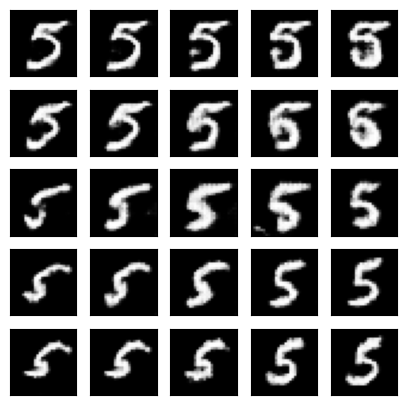

In [ ]:
model_gen.eval()
n = 2
total = 2*n+1
 
plt.figure(figsize=(total, total))
 
num = 1
for i in range(-n, n+1):
  for j in range(-n, n+1):
    ax = plt.subplot(total, total, num)
    num += 1
    h = torch.tensor([[1 * i / n, 1 * j / n]], dtype=torch.float32)
    predict = model_gen(h.to(device))
    predict = predict.detach().squeeze()
    dec_img = predict.cpu().numpy()
 
    plt.imshow(dec_img, cmap='gray')
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
 

# теперь это вполне четкие не смазанные изображения
plt.show()

Генеративно-состязательные сети, как правило, долго обучаются в сравнении с обычными сетями. 

Здесь нам приходится подстраивать весовые коэффициенты отдельно для дискриминатора, затем для генератора и это конкурирующее обучение необходимо повторять много раз для достижения приемлемых результатов. Поэтому число эпох вполне может достигать 100 и более. 

Дополнительные сложности при обучении возникают из-за взаимного влияния дискриминатора и генератора друг на друга. 

Вполне может возникнуть ситуация, когда градиенты генератора будут близки к нулю и обучение попадает в некую ловушку, когда недообученный дискриминатор хорошо различает фейковые изображения недообученного генератора. При этом генератор дальше не обучается из-за этих малых градиентов. 

Но все это можно преодолеть при грамотном подходе к обучению.

### Задание 5

1. Выбрать датасет для обучения модели GAN
2. Адаптировать модель GAN под ваш датасет и обучить ее.
3. Сохранить полученную модель.
4. Подготовить отчет с примерами применения вашей модели. К отчету приложить обученную модель